# Wellbore TVT Prediction using HistGradientBoosting


This notebook predicts True Vertical Thickness (TVT) for unseen wellbore sections using machine learning. The workflow includes data loading, exploratory data analysis (EDA), feature engineering, model training, validation, and submission generation.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/AI_wellbore_geology_prediction_task_en.pptx
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/75d20a82__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b0f53bf4__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/e47

In [2]:
import pandas as pd

# One training horizontal well
h = pd.read_csv("/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/000d7d20__horizontal_well.csv")
print(h.head())
print(h.columns)
print(h.shape)

        MD           X           Y        Z     ANCC    ASTNU    ASTNL  \
0  11467.0  2983525.16  1069022.09 -9258.57 -9395.81 -9569.86 -9597.64   
1  11468.0  2983525.18  1069022.30 -9259.55 -9395.75 -9569.80 -9597.58   
2  11469.0  2983525.20  1069022.52 -9260.52 -9395.69 -9569.74 -9597.52   
3  11470.0  2983525.22  1069022.73 -9261.50 -9395.64 -9569.69 -9597.47   
4  11471.0  2983525.25  1069022.95 -9262.47 -9395.58 -9569.63 -9597.41   

     EGFDU    EGFDL     BUDA       TVT          GR  TVT_input  
0 -9670.99 -9705.96 -9846.35  11236.02  115.692586   11236.02  
1 -9670.93 -9705.90 -9846.29  11237.05  115.584293   11237.05  
2 -9670.87 -9705.84 -9846.23  11238.09  135.446960   11238.09  
3 -9670.82 -9705.79 -9846.18  11239.12  140.401346   11239.12  
4 -9670.76 -9705.73 -9846.12  11240.15  111.270638   11240.15  
Index(['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA',
       'TVT', 'GR', 'TVT_input'],
      dtype='object')
(5278, 13)


In [3]:
t = pd.read_csv("/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/000d7d20__typewell.csv")
print(t.head())
print(t.columns)
print(t.shape)

        TVT      GR Geology
0  11223.95  126.11     NaN
1  11224.45  128.22     NaN
2  11224.95  128.72     NaN
3  11225.45  128.12     NaN
4  11225.95  125.29     NaN
Index(['TVT', 'GR', 'Geology'], dtype='object')
(1296, 3)


In [4]:
sample = pd.read_csv(
    "/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv"
)
print(sample.head())
print(sample.shape)

              id  tvt
0  000d7d20_1442  0.0
1  000d7d20_1443  0.0
2  000d7d20_1444  0.0
3  000d7d20_1445  0.0
4  000d7d20_1446  0.0
(14151, 2)


In [5]:
from pathlib import Path

train_dir = Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction/train")

horizontal = sorted(train_dir.glob("*__horizontal_well.csv"))
typewell = sorted(train_dir.glob("*__typewell.csv"))

print("Horizontal:", len(horizontal))
print("Typewell:", len(typewell))

print(horizontal[:5])
print(typewell[:5])

Horizontal: 773
Typewell: 773
[PosixPath('/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/000d7d20__horizontal_well.csv'), PosixPath('/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/00bbac68__horizontal_well.csv'), PosixPath('/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/00e12e8b__horizontal_well.csv'), PosixPath('/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/015fe0d2__horizontal_well.csv'), PosixPath('/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/01869cd4__horizontal_well.csv')]
[PosixPath('/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/000d7d20__typewell.csv'), PosixPath('/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/00bbac68__typewell.csv'), PosixPath('/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/00e12e8b__typewell.csv'), PosixPath('/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/015fe0d2__typewell.csv'

In [6]:
h_ids = {f.name.split("__")[0] for f in horizontal}
t_ids = {f.name.split("__")[0] for f in typewell}

print("Matching wells:", len(h_ids & t_ids))
print("Horizontal only:", len(h_ids - t_ids))
print("Typewell only:", len(t_ids - h_ids))

Matching wells: 773
Horizontal only: 0
Typewell only: 0


In [7]:
## Loading the data correctly

from pathlib import Path
import pandas as pd

TRAIN_DIR = Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction/train")
TEST_DIR = Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction/test")

train_horizontal = sorted(TRAIN_DIR.glob("*__horizontal_well.csv"))
train_typewell = sorted(TRAIN_DIR.glob("*__typewell.csv"))

test_horizontal = sorted(TEST_DIR.glob("*__horizontal_well.csv"))
test_typewell = sorted(TEST_DIR.glob("*__typewell.csv"))

print(f"Training horizontal wells: {len(train_horizontal)}")
print(f"Training type wells: {len(train_typewell)}")
print(f"Test horizontal wells: {len(test_horizontal)}")
print(f"Test type wells: {len(test_typewell)}")

Training horizontal wells: 773
Training type wells: 773
Test horizontal wells: 3
Test type wells: 3


In [8]:
##Read all training horizontal wells

horizontal_train = []

for file in train_horizontal:
    df = pd.read_csv(file)
    df["well_id"] = file.stem.split("__")[0]
    horizontal_train.append(df)

horizontal_train = pd.concat(horizontal_train, ignore_index=True)

print(horizontal_train.shape)
horizontal_train.head()

(5092255, 14)


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,well_id
0,11467.0,2983525.16,1069022.09,-9258.57,-9395.81,-9569.86,-9597.64,-9670.99,-9705.96,-9846.35,11236.02,115.692586,11236.02,000d7d20
1,11468.0,2983525.18,1069022.30,-9259.55,-9395.75,-9569.80,-9597.58,-9670.93,-9705.90,-9846.29,11237.05,115.584293,11237.05,000d7d20
2,11469.0,2983525.20,1069022.52,-9260.52,-9395.69,-9569.74,-9597.52,-9670.87,-9705.84,-9846.23,11238.09,135.446960,11238.09,000d7d20
3,11470.0,2983525.22,1069022.73,-9261.50,-9395.64,-9569.69,-9597.47,-9670.82,-9705.79,-9846.18,11239.12,140.401346,11239.12,000d7d20
4,11471.0,2983525.25,1069022.95,-9262.47,-9395.58,-9569.63,-9597.41,-9670.76,-9705.73,-9846.12,11240.15,111.270638,11240.15,000d7d20


In [9]:
## Reading all training type wells

typewell_train = []

for file in train_typewell:
    df = pd.read_csv(file)
    df["well_id"] = file.stem.split("__")[0]
    typewell_train.append(df)

typewell_train = pd.concat(typewell_train, ignore_index=True)

print(typewell_train.shape)
typewell_train.head()

(1567045, 4)


,TVT,GR,Geology,well_id
0,11223.95,126.11,NaN,000d7d20
1,11224.45,128.22,NaN,000d7d20
2,11224.95,128.72,NaN,000d7d20
3,11225.45,128.12,NaN,000d7d20
4,11225.95,125.29,NaN,000d7d20


# Exploratory Data Analysis

The dataset was explored to understand feature distributions, missing values, and relationships with the target variable. Correlation analysis and visualizations were used to identify the most informative features for TVT prediction.

In [10]:
print("Horizontal Wells")
display(horizontal_train.describe())

print("\nType Wells")
display(typewell_train.describe())

Horizontal Wells


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
count,5.092255e+06,5.092255e+06,5.092255e+06,5.092255e+06,5.046621e+06,5.092255e+06,5.092255e+06,5.092255e+06,5.086188e+06,5.092255e+06,5.092255e+06,3.584283e+06,1.308266e+06
mean,1.431686e+04,2.965999e+06,1.074748e+06,-9.390812e+03,-9.008724e+03,-9.192691e+03,-9.257051e+03,-9.350495e+03,-9.392205e+03,-9.516918e+03,1.150364e+04,8.775241e+01,1.138214e+04
std,2.206524e+03,4.774998e+04,3.560354e+04,6.344759e+02,6.376223e+02,6.418644e+02,6.268797e+02,6.219953e+02,6.222202e+02,6.364027e+02,6.399711e+02,2.376834e+01,6.631711e+02
min,9.335000e+03,2.855426e+06,1.007176e+06,-1.102765e+04,-1.064731e+04,-1.085279e+04,-1.086558e+04,-1.088758e+04,-1.093235e+04,-1.110473e+04,9.245190e+03,1.388016e+01,9.245190e+03
25%,1.254700e+04,2.917842e+06,1.040716e+06,-9.920910e+03,-9.548060e+03,-9.723750e+03,-9.771820e+03,-9.883505e+03,-9.925562e+03,-1.005426e+04,1.098793e+04,7.249096e+01,1.090497e+04
50%,1.419900e+04,2.986284e+06,1.080803e+06,-9.270310e+03,-8.865570e+03,-9.063210e+03,-9.134010e+03,-9.213220e+03,-9.256610e+03,-9.377050e+03,1.135451e+04,8.585950e+01,1.122422e+04
75%,1.592800e+04,3.006569e+06,1.105967e+06,-8.918930e+03,-8.511810e+03,-8.691070e+03,-8.765320e+03,-8.860120e+03,-8.902370e+03,-9.017110e+03,1.203826e+04,1.010383e+02,1.194713e+04
max,2.296400e+04,3.039107e+06,1.141858e+06,-7.174220e+03,-7.301760e+03,-7.509200e+03,-7.614430e+03,-7.704030e+03,-7.731610e+03,-7.835570e+03,1.289389e+04,4.870329e+02,1.287730e+04



Type Wells


,TVT,GR
count,1.567045e+06,1.567045e+06
mean,1.123414e+04,8.909180e+01
std,7.218583e+02,3.372293e+01
min,9.232650e+03,1.853000e+01
25%,1.071313e+04,6.466000e+01
50%,1.117319e+04,8.973000e+01
75%,1.180912e+04,1.106800e+02
max,1.299153e+04,4.335800e+02


## Numerical Summary

In [11]:
horizontal_train.describe().T

,count,mean,std,min,25%,50%,75%,max
MD,5092255.0,1.431686e+04,2206.523850,9.335000e+03,1.254700e+04,1.419900e+04,1.592800e+04,2.296400e+04
X,5092255.0,2.965999e+06,47749.981497,2.855426e+06,2.917842e+06,2.986284e+06,3.006569e+06,3.039107e+06
Y,5092255.0,1.074748e+06,35603.540240,1.007176e+06,1.040716e+06,1.080803e+06,1.105967e+06,1.141858e+06
Z,5092255.0,-9.390812e+03,634.475915,-1.102765e+04,-9.920910e+03,-9.270310e+03,-8.918930e+03,-7.174220e+03
ANCC,5046621.0,-9.008724e+03,637.622279,-1.064731e+04,-9.548060e+03,-8.865570e+03,-8.511810e+03,-7.301760e+03
ASTNU,5092255.0,-9.192691e+03,641.864443,-1.085279e+04,-9.723750e+03,-9.063210e+03,-8.691070e+03,-7.509200e+03
ASTNL,5092255.0,-9.257051e+03,626.879708,-1.086558e+04,-9.771820e+03,-9.134010e+03,-8.765320e+03,-7.614430e+03
EGFDU,5092255.0,-9.350495e+03,621.995283,-1.088758e+04,-9.883505e+03,-9.213220e+03,-8.860120e+03,-7.704030e+03
EGFDL,5086188.0,-9.392205e+03,622.220203,-1.093235e+04,-9.925562e+03,-9.256610e+03,-8.902370e+03,-7.731610e+03
BUDA,5092255.0,-9.516918e+03,636.402653,-1.110473e+04,-1.005426e+04,-9.377050e+03,-9.017110e+03,-7.835570e+03


In [12]:
typewell_train.describe().T

,count,mean,std,min,25%,50%,75%,max
TVT,1567045.0,11234.144729,721.858283,9232.65,10713.13,11173.19,11809.12,12991.53
GR,1567045.0,89.091801,33.722934,18.53,64.66,89.73,110.68,433.58


In [13]:
horizontal_train.info()

typewell_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5092255 entries, 0 to 5092254
Data columns (total 14 columns):
 #   Column     Dtype  
---  ------     -----  
 0   MD         float64
 1   X          float64
 2   Y          float64
 3   Z          float64
 4   ANCC       float64
 5   ASTNU      float64
 6   ASTNL      float64
 7   EGFDU      float64
 8   EGFDL      float64
 9   BUDA       float64
 10  TVT        float64
 11  GR         float64
 12  TVT_input  float64
 13  well_id    object 
dtypes: float64(13), object(1)
memory usage: 543.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567045 entries, 0 to 1567044
Data columns (total 4 columns):
 #   Column   Non-Null Count    Dtype  
---  ------   --------------    -----  
 0   TVT      1567045 non-null  float64
 1   GR       1567045 non-null  float64
 2   Geology  1043571 non-null  object 
 3   well_id  1567045 non-null  object 
dtypes: float64(2), object(2)
memory usage: 47.8+ MB


 ## Missing Value Heatmap

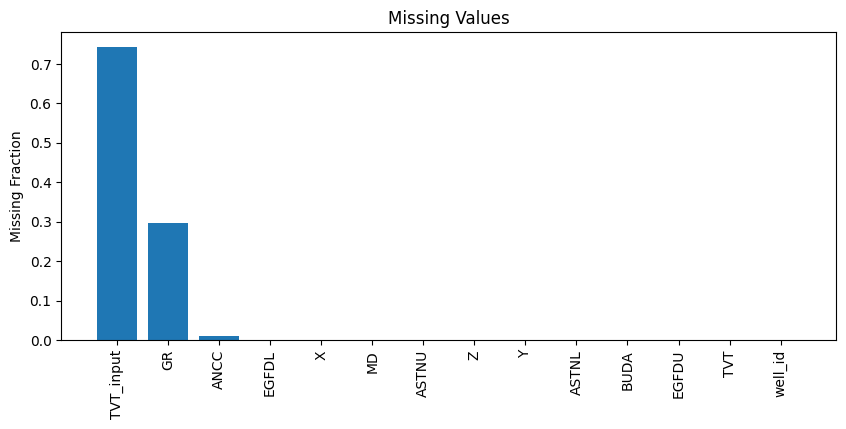

In [14]:
import matplotlib.pyplot as plt

missing = horizontal_train.isnull().mean().sort_values(ascending=False)

plt.figure(figsize=(10,4))
plt.bar(missing.index, missing.values)
plt.xticks(rotation=90)
plt.ylabel("Missing Fraction")
plt.title("Missing Values")
plt.show()

## Target Distribution

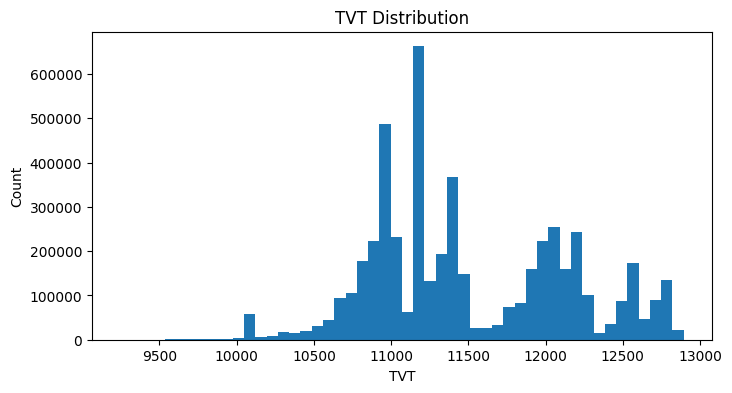

In [15]:
plt.figure(figsize=(8,4))
plt.hist(horizontal_train["TVT"], bins=50)
plt.title("TVT Distribution")
plt.xlabel("TVT")
plt.ylabel("Count")
plt.show()

## Gamma Ray (GR) Distribution

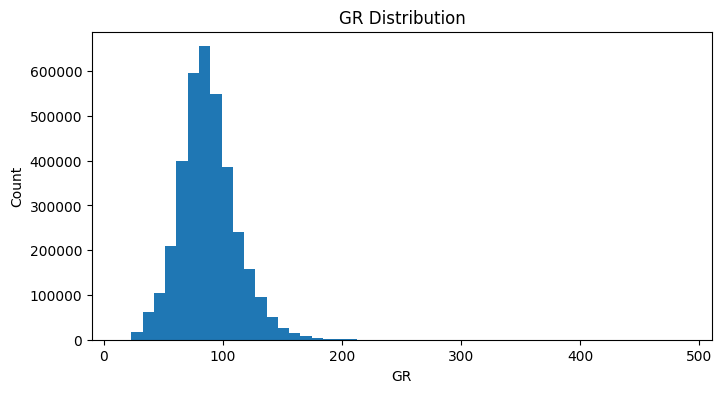

In [16]:
plt.figure(figsize=(8,4))
plt.hist(horizontal_train["GR"], bins=50)
plt.title("GR Distribution")
plt.xlabel("GR")
plt.ylabel("Count")
plt.show()

## Correlation Matrix

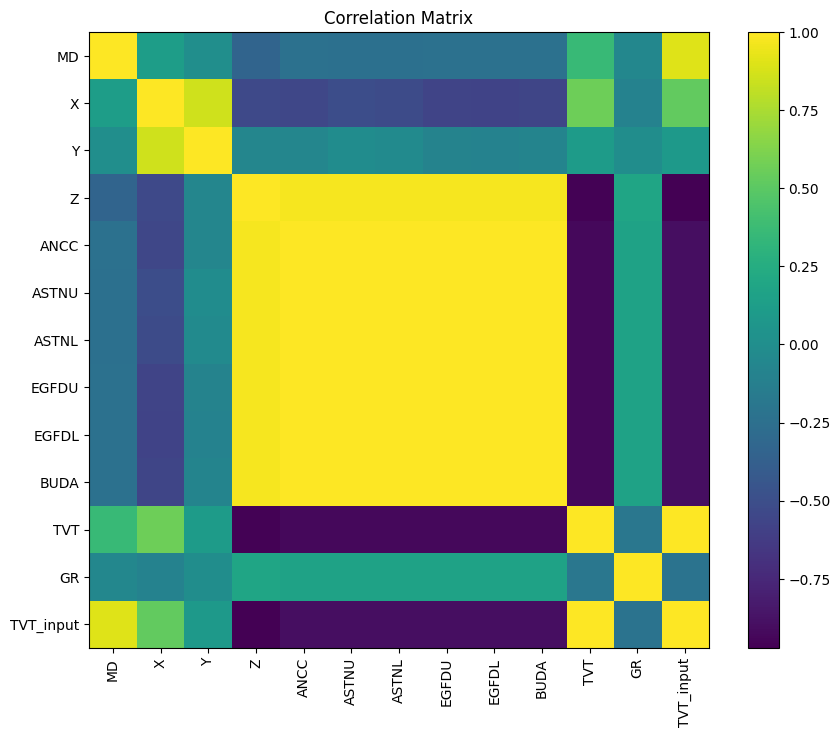

In [17]:
corr = horizontal_train.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

## TVT vs TVT_input 

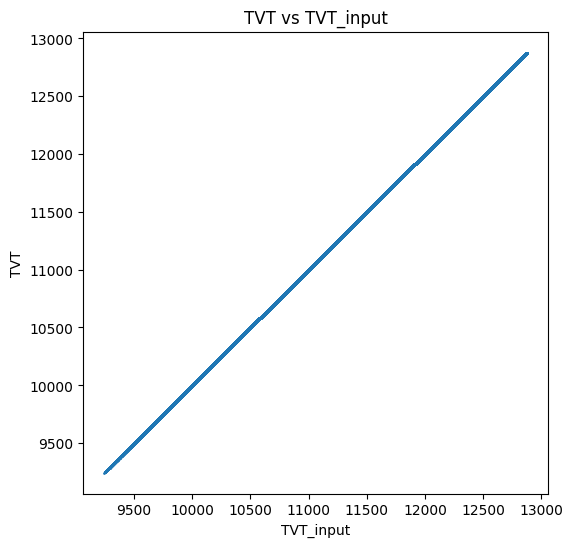

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(
    horizontal_train["TVT_input"],
    horizontal_train["TVT"],
    s=1
)
plt.xlabel("TVT_input")
plt.ylabel("TVT")
plt.title("TVT vs TVT_input")
plt.show()

## Feature Correlation with TVT

In [19]:
corr = (
    horizontal_train
    .select_dtypes(include="number")
    .corr()["TVT"]
    .sort_values()
)

print(corr)

Z           -0.960659
ANCC        -0.931361
BUDA        -0.931200
ASTNU       -0.929938
EGFDU       -0.929894
EGFDL       -0.929738
ASTNL       -0.929140
GR          -0.189338
Y            0.112720
MD           0.356631
X            0.563646
TVT          1.000000
TVT_input    1.000000
Name: TVT, dtype: float64


## Well Length Distribution

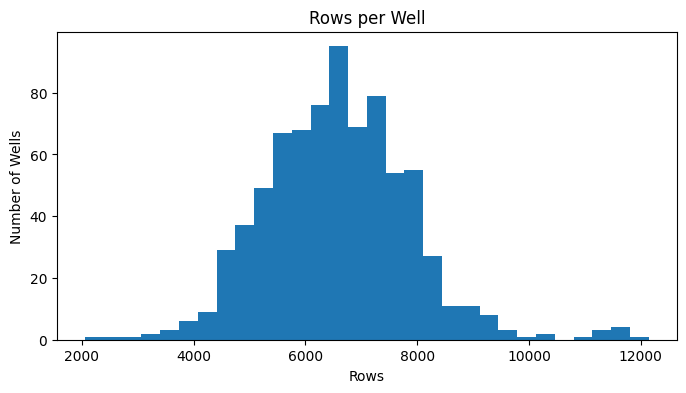

In [20]:
well_sizes = horizontal_train.groupby("well_id").size()

plt.figure(figsize=(8,4))
plt.hist(well_sizes, bins=30)
plt.title("Rows per Well")
plt.xlabel("Rows")
plt.ylabel("Number of Wells")
plt.show()

##  Geology Distribution

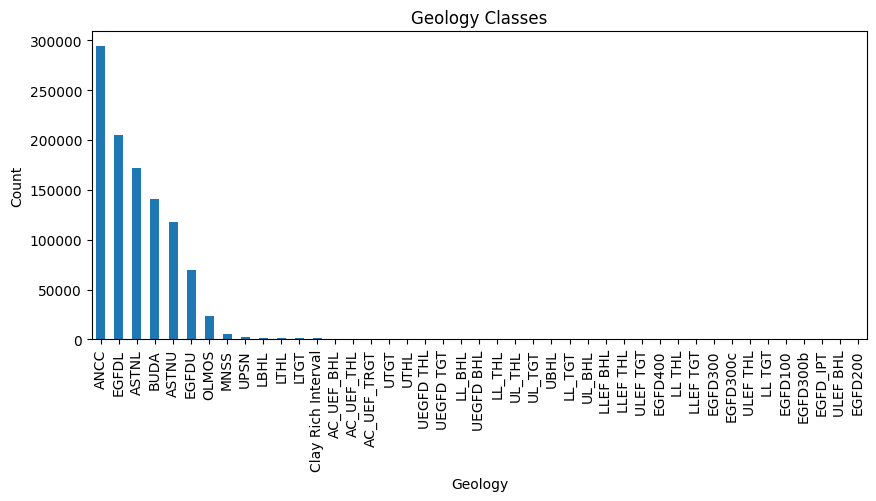

In [21]:
typewell_train["Geology"].value_counts().plot(kind="bar", figsize=(10,4))

plt.title("Geology Classes")
plt.ylabel("Count")
plt.show()

## Coordinate Relationships

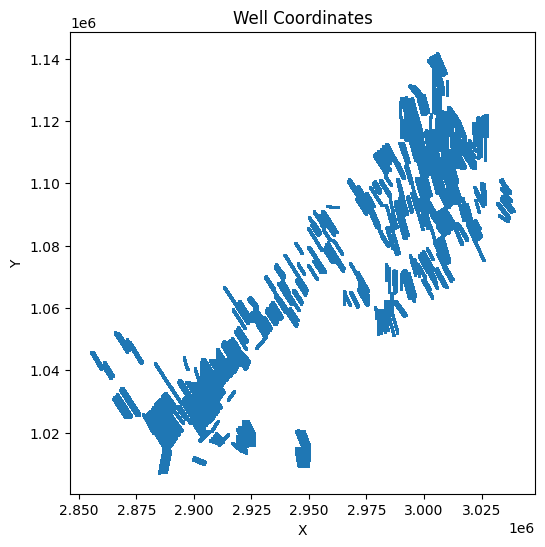

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(
    horizontal_train["X"],
    horizontal_train["Y"],
    s=1
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Well Coordinates")
plt.show()

## TVT Along Measured Depth

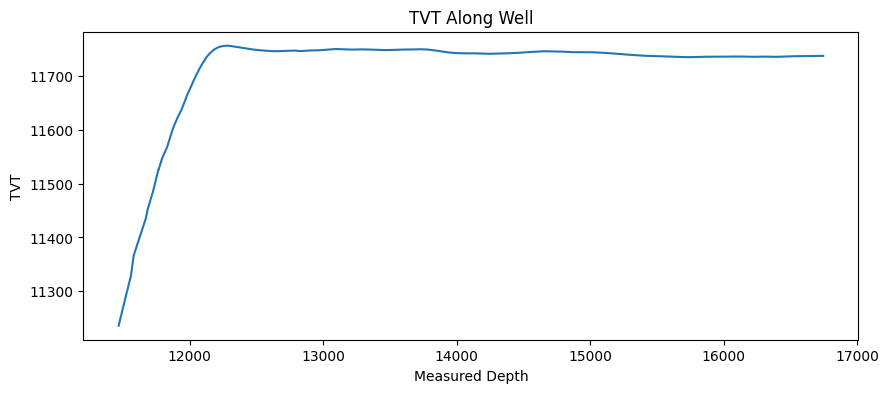

In [23]:
sample = horizontal_train[
    horizontal_train["well_id"] == horizontal_train["well_id"].iloc[0]
]

plt.figure(figsize=(10,4))
plt.plot(sample["MD"], sample["TVT"])
plt.xlabel("Measured Depth")
plt.ylabel("TVT")
plt.title("TVT Along Well")
plt.show()

## GR Along Measured Depth

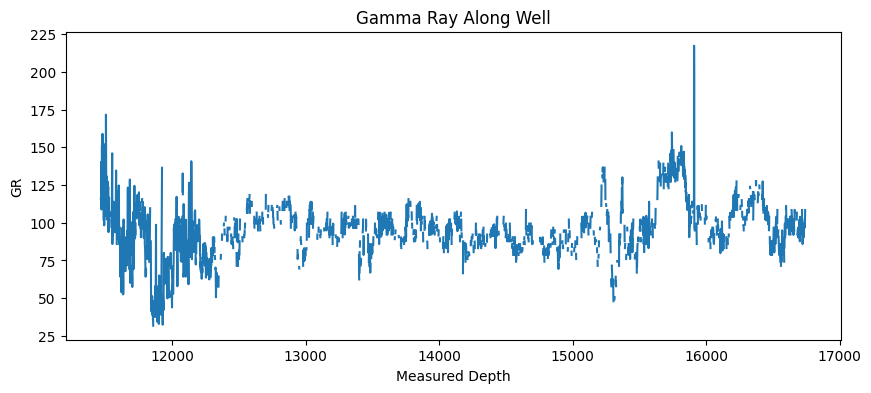

In [24]:
plt.figure(figsize=(10,4))
plt.plot(sample["MD"], sample["GR"])
plt.xlabel("Measured Depth")
plt.ylabel("GR")
plt.title("Gamma Ray Along Well")
plt.show()

## Boxplots for Numeric Features

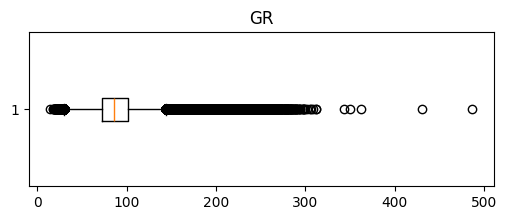

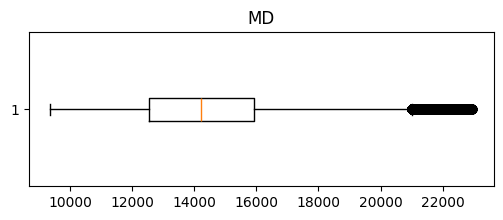

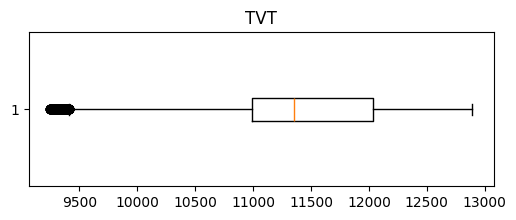

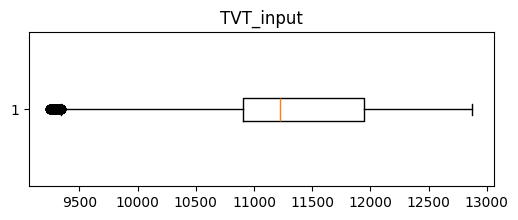

In [25]:
numeric = ["GR", "MD", "TVT", "TVT_input"]

for col in numeric:
    plt.figure(figsize=(6,2))
    plt.boxplot(horizontal_train[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

# Missing Values

In [26]:
horizontal_train.isnull().mean().sort_values(ascending=False)

TVT_input    0.743087
GR           0.296130
ANCC         0.008961
EGFDL        0.001191
X            0.000000
MD           0.000000
ASTNU        0.000000
Z            0.000000
Y            0.000000
ASTNL        0.000000
BUDA         0.000000
EGFDU        0.000000
TVT          0.000000
well_id      0.000000
dtype: float64

In [27]:
typewell_train.isnull().mean().sort_values(ascending=False)

Geology    0.334052
TVT        0.000000
GR         0.000000
well_id    0.000000
dtype: float64

## Number of Wells

In [28]:
print("Unique wells (horizontal):", horizontal_train["well_id"].nunique())
print("Unique wells (typewell):", typewell_train["well_id"].nunique())

Unique wells (horizontal): 773
Unique wells (typewell): 773


## Rows per Well

In [29]:
rows_per_well = horizontal_train.groupby("well_id").size()

rows_per_well.describe()

count      773.000000
mean      6587.652005
std       1311.463547
min       2058.000000
25%       5706.000000
50%       6576.000000
75%       7388.000000
max      12141.000000
dtype: float64

## Distribution of Rows

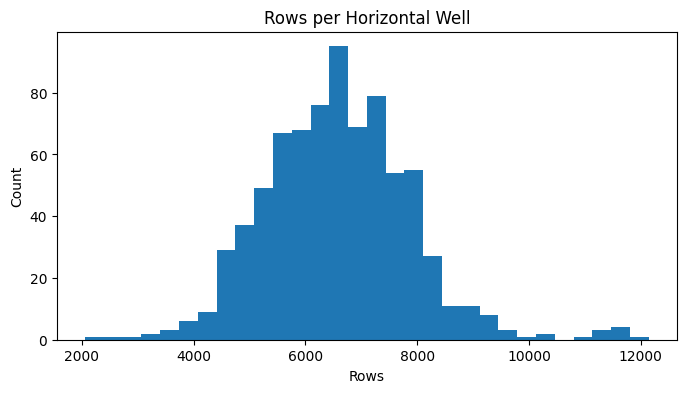

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(rows_per_well, bins=30)
plt.title("Rows per Horizontal Well")
plt.xlabel("Rows")
plt.ylabel("Count")
plt.show()

## Feature Engineering

Several domain-inspired features were created to improve model performance, including:

- Relative measured depth
- Distance from the start of each well
- Vertical displacement (`dz`)
- Rolling mean and standard deviation of GR
- Horizontal distance (`xy_distance`)
- Type-well statistical features (mean, std, min, max, row count)

## summary features for each type well

In [31]:
typewell_features = (
    typewell_train
    .groupby("well_id")
    .agg(
        type_rows=("TVT", "count"),
        type_tvt_mean=("TVT", "mean"),
        type_tvt_std=("TVT", "std"),
        type_tvt_min=("TVT", "min"),
        type_tvt_max=("TVT", "max"),
        type_gr_mean=("GR", "mean"),
        type_gr_std=("GR", "std"),
        type_gr_min=("GR", "min"),
        type_gr_max=("GR", "max"),
    )
    .reset_index()
)

typewell_features.head()

,well_id,type_rows,type_tvt_mean,type_tvt_std,type_tvt_min,type_tvt_max,type_gr_mean,type_gr_std,type_gr_min,type_gr_max
0,000d7d20,1296,11547.70,187.133642,11223.95,11871.45,83.257639,26.251321,28.66,158.18
1,00bbac68,1946,11880.70,280.953065,11394.45,12366.95,92.344173,27.661227,31.86,215.44
2,00e12e8b,2556,11232.70,368.998984,10593.95,11871.45,95.769014,23.501279,28.66,195.42
3,015fe0d2,1265,12050.95,182.659177,11734.95,12366.95,81.735012,27.579924,31.86,215.44
4,01869cd4,1052,11608.70,151.915272,11345.95,11871.45,76.892262,24.329898,28.66,145.21


## Adding the most common geology

In [32]:
major_geology = (
    typewell_train
    .groupby("well_id")["Geology"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
    .reset_index(name="major_geology")
)

typewell_features = typewell_features.merge(
    major_geology,
    on="well_id",
    how="left"
)

## Merge with horizontal wells

In [33]:
horizontal_train = horizontal_train.merge(
    typewell_features,
    on="well_id",
    how="left"
)

horizontal_train.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,...,type_rows,type_tvt_mean,type_tvt_std,type_tvt_min,type_tvt_max,type_gr_mean,type_gr_std,type_gr_min,type_gr_max,major_geology
0,11467.0,2983525.16,1069022.09,-9258.57,-9395.81,-9569.86,-9597.64,-9670.99,-9705.96,-9846.35,...,1296,11547.7,187.133642,11223.95,11871.45,83.257639,26.251321,28.66,158.18,ANCC
1,11468.0,2983525.18,1069022.30,-9259.55,-9395.75,-9569.80,-9597.58,-9670.93,-9705.90,-9846.29,...,1296,11547.7,187.133642,11223.95,11871.45,83.257639,26.251321,28.66,158.18,ANCC
2,11469.0,2983525.20,1069022.52,-9260.52,-9395.69,-9569.74,-9597.52,-9670.87,-9705.84,-9846.23,...,1296,11547.7,187.133642,11223.95,11871.45,83.257639,26.251321,28.66,158.18,ANCC
3,11470.0,2983525.22,1069022.73,-9261.50,-9395.64,-9569.69,-9597.47,-9670.82,-9705.79,-9846.18,...,1296,11547.7,187.133642,11223.95,11871.45,83.257639,26.251321,28.66,158.18,ANCC
4,11471.0,2983525.25,1069022.95,-9262.47,-9395.58,-9569.63,-9597.41,-9670.76,-9705.73,-9846.12,...,1296,11547.7,187.133642,11223.95,11871.45,83.257639,26.251321,28.66,158.18,ANCC


## Relative depth inside each well

In [34]:
horizontal_train["relative_md"] = (
    horizontal_train["MD"] /
    horizontal_train.groupby("well_id")["MD"].transform("max")
)

## Depth from start of well

In [35]:
horizontal_train["md_from_start"] = (
    horizontal_train["MD"] -
    horizontal_train.groupby("well_id")["MD"].transform("min")
)

## Delta MD

In [36]:
horizontal_train["delta_md"] = (
    horizontal_train
    .groupby("well_id")["MD"]
    .diff()
    .fillna(0)
)

## Rolling GR mean

In [37]:
horizontal_train["gr_roll_mean_5"] = (
    horizontal_train
    .groupby("well_id")["GR"]
    .transform(lambda s: s.rolling(5, min_periods=1).mean())
)

## Rolling GR standard deviation

In [38]:
horizontal_train["gr_roll_std_5"] = (
    horizontal_train
    .groupby("well_id")["GR"]
    .transform(lambda s: s.rolling(5, min_periods=1).std())
    .fillna(0)
)

##  GR change

In [39]:
horizontal_train["gr_diff"] = (
    horizontal_train
    .groupby("well_id")["GR"]
    .diff()
    .fillna(0)
)

## Coordinate distance from the start

In [40]:
horizontal_train["dx"] = (
    horizontal_train["X"] -
    horizontal_train.groupby("well_id")["X"].transform("first")
)

horizontal_train["dy"] = (
    horizontal_train["Y"] -
    horizontal_train.groupby("well_id")["Y"].transform("first")
)

horizontal_train["dz"] = (
    horizontal_train["Z"] -
    horizontal_train.groupby("well_id")["Z"].transform("first")
)

## Horizontal displacement

In [41]:
import numpy as np

horizontal_train["xy_distance"] = np.sqrt(
    horizontal_train["dx"]**2 +
    horizontal_train["dy"]**2
)

## Encode geology

In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

horizontal_train["major_geology"] = le.fit_transform(
    horizontal_train["major_geology"].fillna("Unknown")
)

## inspecting which features are most informative with

In [43]:
corr = (
    horizontal_train
    .select_dtypes(include="number")
    .corr()["TVT"]
    .sort_values(ascending=False)
)

print(corr)

TVT_input         1.000000
TVT               1.000000
type_tvt_max      0.971819
type_tvt_mean     0.967741
type_tvt_min      0.943948
X                 0.563646
MD                0.356631
relative_md       0.168179
Y                 0.112720
major_geology     0.095235
md_from_start     0.088663
xy_distance       0.081299
type_tvt_std      0.068116
type_gr_max       0.067864
dy                0.032409
delta_md          0.012883
type_gr_min       0.004445
dx                0.002254
gr_diff           0.000980
gr_roll_std_5    -0.082977
type_rows        -0.092016
dz               -0.156338
type_gr_mean     -0.160973
gr_roll_mean_5   -0.182655
GR               -0.189338
type_gr_std      -0.324300
ASTNL            -0.929140
EGFDL            -0.929738
EGFDU            -0.929894
ASTNU            -0.929938
BUDA             -0.931200
ANCC             -0.931361
Z                -0.960659
Name: TVT, dtype: float64


In [44]:
print(horizontal_train.columns[horizontal_train.columns.str.endswith("_x")])
print(horizontal_train.columns[horizontal_train.columns.str.endswith("_y")])

Index([], dtype='object')
Index([], dtype='object')


Z                -0.960659
ANCC             -0.931361
BUDA             -0.931200
ASTNU            -0.929938
EGFDU            -0.929894
EGFDL            -0.929738
ASTNL            -0.929140
type_gr_std      -0.324300
GR               -0.189338
gr_roll_mean_5   -0.182655
type_gr_mean     -0.160973
dz               -0.156338
type_rows        -0.092016
gr_roll_std_5    -0.082977
gr_diff           0.000980
dx                0.002254
type_gr_min       0.004445
delta_md          0.012883
dy                0.032409
type_gr_max       0.067864
type_tvt_std      0.068116
xy_distance       0.081299
md_from_start     0.088663
major_geology     0.095235
Y                 0.112720
relative_md       0.168179
MD                0.356631
X                 0.563646
type_tvt_min      0.943948
type_tvt_mean     0.967741
type_tvt_max      0.971819
TVT               1.000000
Name: TVT, dtype: float64


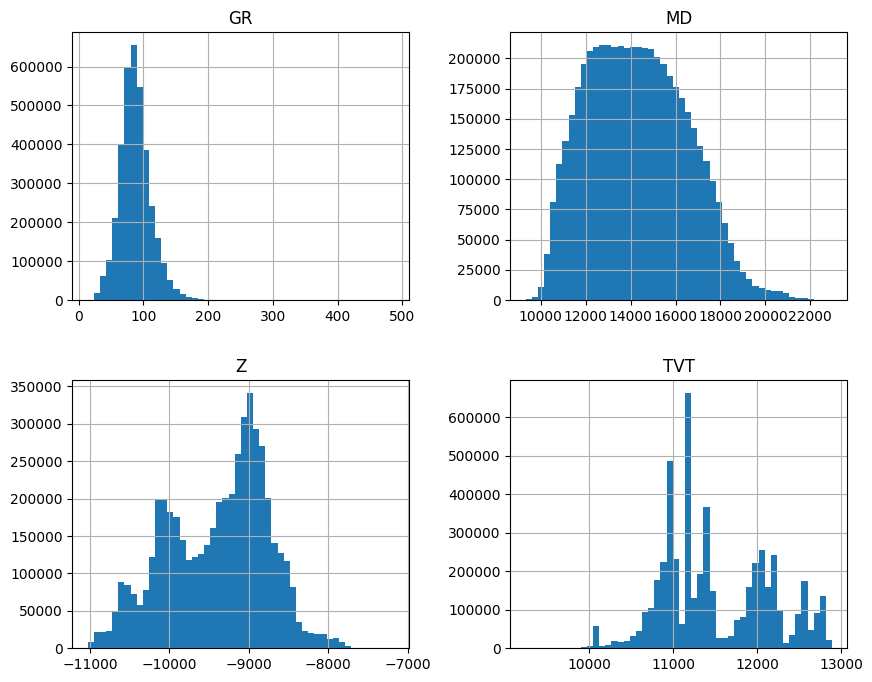

In [45]:
# Feature distributions
horizontal_train.hist(
    column=["GR", "MD", "Z", "TVT"],
    figsize=(10, 8),
    bins=50
)

# Correlation without TVT_input
corr = (
    horizontal_train
    .drop(columns=["TVT_input"])
    .select_dtypes(include="number")
    .corr()["TVT"]
    .sort_values()
)
print(corr)

(horizontal_train["type_tvt_mean_x"] == horizontal_train["type_tvt_mean_y"]).all()

(horizontal_train["type_gr_mean_x"] == horizontal_train["type_gr_mean_y"]).all()
(horizontal_train["type_rows_x"] == horizontal_train["type_rows_y"]).all()

In [46]:
# Drop duplicate _y columns
cols_to_drop = [c for c in horizontal_train.columns if c.endswith("_y")]

horizontal_train = horizontal_train.drop(columns=cols_to_drop)

# Remove "_x" suffix from remaining columns
horizontal_train.columns = horizontal_train.columns.str.replace("_x", "", regex=False)

print(horizontal_train.shape)

(5092255, 34)


In [47]:
print(horizontal_train.columns[horizontal_train.columns.str.endswith("_x")])
print(horizontal_train.columns[horizontal_train.columns.str.endswith("_y")])

Index([], dtype='object')
Index([], dtype='object')


In [48]:
corr = (
    horizontal_train
    .drop(columns=["TVT_input"])
    .select_dtypes(include="number")
    .corr()["TVT"]
    .sort_values()
)

print(corr)

Z                -0.960659
ANCC             -0.931361
BUDA             -0.931200
ASTNU            -0.929938
EGFDU            -0.929894
EGFDL            -0.929738
ASTNL            -0.929140
type_gr_std      -0.324300
GR               -0.189338
gr_roll_mean_5   -0.182655
type_gr_mean     -0.160973
dz               -0.156338
type_rows        -0.092016
gr_roll_std_5    -0.082977
gr_diff           0.000980
dx                0.002254
type_gr_min       0.004445
delta_md          0.012883
dy                0.032409
type_gr_max       0.067864
type_tvt_std      0.068116
xy_distance       0.081299
md_from_start     0.088663
major_geology     0.095235
Y                 0.112720
relative_md       0.168179
MD                0.356631
X                 0.563646
type_tvt_min      0.943948
type_tvt_mean     0.967741
type_tvt_max      0.971819
TVT               1.000000
Name: TVT, dtype: float64


In [49]:
## removing features with almost no linear relationship to simplify the model

low_corr = [
    "gr_diff",
    "dx",
    "dy",
    "delta_md",
    "type_gr_min"
]

horizontal_train = horizontal_train.drop(columns=low_corr)

In [50]:
print(horizontal_train.columns)

Index(['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA',
       'TVT', 'GR', 'TVT_input', 'well_id', 'type_rows', 'type_tvt_mean',
       'type_tvt_std', 'type_tvt_min', 'type_tvt_max', 'type_gr_mean',
       'type_gr_std', 'type_gr_max', 'major_geology', 'relative_md',
       'md_from_start', 'gr_roll_mean_5', 'gr_roll_std_5', 'dz',
       'xy_distance'],
      dtype='object')


In [51]:
target = "TVT"

X = horizontal_train.drop(columns=["TVT", "well_id"])
y = horizontal_train["TVT"]

print(X.shape)
print(y.shape)

(5092255, 27)
(5092255,)


In [52]:
## loading all test horizontal wells

from pathlib import Path
import pandas as pd

TEST_DIR = Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction/test")

test_horizontal_files = sorted(TEST_DIR.glob("*__horizontal_well.csv"))

horizontal_test = []

for file in test_horizontal_files:
    df = pd.read_csv(file)
    df["well_id"] = file.stem.split("__")[0]
    horizontal_test.append(df)

horizontal_test = pd.concat(horizontal_test, ignore_index=True)

print(horizontal_test.shape)
horizontal_test.head()

(19221, 7)


,MD,X,Y,Z,GR,TVT_input,well_id
0,11467.0,2983525.16,1069022.09,-9258.57,115.692586,11236.02,000d7d20
1,11468.0,2983525.18,1069022.30,-9259.55,115.584293,11237.05,000d7d20
2,11469.0,2983525.20,1069022.52,-9260.52,135.446960,11238.09,000d7d20
3,11470.0,2983525.22,1069022.73,-9261.50,140.401346,11239.12,000d7d20
4,11471.0,2983525.25,1069022.95,-9262.47,111.270638,11240.15,000d7d20


In [53]:
## loading all test type wells
test_type_files = sorted(TEST_DIR.glob("*__typewell.csv"))

typewell_test = []

for file in test_type_files:
    df = pd.read_csv(file)
    df["well_id"] = file.stem.split("__")[0]
    typewell_test.append(df)

typewell_test = pd.concat(typewell_test, ignore_index=True)

print(typewell_test.shape)
typewell_test.head()

(5798, 3)


,TVT,GR,well_id
0,11223.95,126.11,000d7d20
1,11224.45,128.22,000d7d20
2,11224.95,128.72,000d7d20
3,11225.45,128.12,000d7d20
4,11225.95,125.29,000d7d20


In [54]:
print(horizontal_test.shape)
print(typewell_test.shape)

(19221, 7)
(5798, 3)


In [55]:
print(horizontal_test.columns.tolist())
print(typewell_test.columns.tolist())

['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input', 'well_id']
['TVT', 'GR', 'well_id']


In [56]:
common_features = [
    "MD",
    "X",
    "Y",
    "Z",
    "GR",
    "TVT_input",
    "relative_md",
    "md_from_start",
    "delta_md",
    "gr_roll_mean_5",
    "gr_roll_std_5",
    "gr_diff",
    "dx",
    "dy",
    "dz",
    "xy_distance",
    "type_rows",
    "type_tvt_mean",
    "type_tvt_std",
    "type_tvt_min",
    "type_tvt_max",
    "type_gr_mean",
    "type_gr_std",
    "type_gr_min",
    "type_gr_max",
]

In [57]:
print("Train columns:")
print(sorted(horizontal_train.columns.tolist()))

Train columns:
['ANCC', 'ASTNL', 'ASTNU', 'BUDA', 'EGFDL', 'EGFDU', 'GR', 'MD', 'TVT', 'TVT_input', 'X', 'Y', 'Z', 'dz', 'gr_roll_mean_5', 'gr_roll_std_5', 'major_geology', 'md_from_start', 'relative_md', 'type_gr_max', 'type_gr_mean', 'type_gr_std', 'type_rows', 'type_tvt_max', 'type_tvt_mean', 'type_tvt_min', 'type_tvt_std', 'well_id', 'xy_distance']


In [58]:
print("Test columns:")
print(sorted(horizontal_test.columns.tolist()))

Test columns:
['GR', 'MD', 'TVT_input', 'X', 'Y', 'Z', 'well_id']


In [59]:
train_cols = set(horizontal_train.columns)
test_cols = set(horizontal_test.columns)

print("Only in train:")
print(sorted(train_cols - test_cols))

print("\nOnly in test:")
print(sorted(test_cols - train_cols))

Only in train:
['ANCC', 'ASTNL', 'ASTNU', 'BUDA', 'EGFDL', 'EGFDU', 'TVT', 'dz', 'gr_roll_mean_5', 'gr_roll_std_5', 'major_geology', 'md_from_start', 'relative_md', 'type_gr_max', 'type_gr_mean', 'type_gr_std', 'type_rows', 'type_tvt_max', 'type_tvt_mean', 'type_tvt_min', 'type_tvt_std', 'xy_distance']

Only in test:
[]


In [60]:
# Relative MD
horizontal_test["relative_md"] = (
    horizontal_test["MD"] /
    horizontal_test.groupby("well_id")["MD"].transform("max")
)

# MD from start
horizontal_test["md_from_start"] = (
    horizontal_test["MD"] -
    horizontal_test.groupby("well_id")["MD"].transform("min")
)

# dz
horizontal_test["dz"] = (
    horizontal_test["Z"] -
    horizontal_test.groupby("well_id")["Z"].transform("first")
)

# Rolling GR
horizontal_test["gr_roll_mean_5"] = (
    horizontal_test.groupby("well_id")["GR"]
    .transform(lambda s: s.rolling(5, min_periods=1).mean())
)

horizontal_test["gr_roll_std_5"] = (
    horizontal_test.groupby("well_id")["GR"]
    .transform(lambda s: s.rolling(5, min_periods=1).std())
    .fillna(0)
)

# Horizontal distance
dx = horizontal_test["X"] - horizontal_test.groupby("well_id")["X"].transform("first")
dy = horizontal_test["Y"] - horizontal_test.groupby("well_id")["Y"].transform("first")

horizontal_test["xy_distance"] = np.sqrt(dx**2 + dy**2)

In [61]:
typewell_test_features = (
    typewell_test
    .groupby("well_id")
    .agg(
        type_rows=("TVT", "count"),
        type_tvt_mean=("TVT", "mean"),
        type_tvt_std=("TVT", "std"),
        type_tvt_min=("TVT", "min"),
        type_tvt_max=("TVT", "max"),
        type_gr_mean=("GR", "mean"),
        type_gr_std=("GR", "std"),
        type_gr_max=("GR", "max"),
    )
    .reset_index()
)

horizontal_test = horizontal_test.merge(
    typewell_test_features,
    on="well_id",
    how="left"
)

In [62]:
print(horizontal_train.shape)
print(horizontal_test.shape)

print(set(horizontal_train.columns) - set(horizontal_test.columns))

(5092255, 29)
(19221, 21)
{'EGFDL', 'BUDA', 'ASTNU', 'EGFDU', 'TVT', 'ASTNL', 'ANCC', 'major_geology'}


In [63]:
print(horizontal_test.columns.tolist())

['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input', 'well_id', 'relative_md', 'md_from_start', 'dz', 'gr_roll_mean_5', 'gr_roll_std_5', 'xy_distance', 'type_rows', 'type_tvt_mean', 'type_tvt_std', 'type_tvt_min', 'type_tvt_max', 'type_gr_mean', 'type_gr_std', 'type_gr_max']


In [64]:
for c in horizontal_test.columns:
    print(c)

MD
X
Y
Z
GR
TVT_input
well_id
relative_md
md_from_start
dz
gr_roll_mean_5
gr_roll_std_5
xy_distance
type_rows
type_tvt_mean
type_tvt_std
type_tvt_min
type_tvt_max
type_gr_mean
type_gr_std
type_gr_max


In [65]:
# Drop duplicate _y columns
cols_to_drop = [c for c in horizontal_test.columns if c.endswith("_y")]
horizontal_test = horizontal_test.drop(columns=cols_to_drop)

# Remove "_x" suffix
horizontal_test.columns = horizontal_test.columns.str.replace("_x", "", regex=False)

print(horizontal_test.columns)

Index(['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input', 'well_id', 'relative_md',
       'md_from_start', 'dz', 'gr_roll_mean_5', 'gr_roll_std_5', 'xy_distance',
       'type_rows', 'type_tvt_mean', 'type_tvt_std', 'type_tvt_min',
       'type_tvt_max', 'type_gr_mean', 'type_gr_std', 'type_gr_max'],
      dtype='object')


In [66]:
print(set(horizontal_train.columns) - set(horizontal_test.columns))

{'EGFDL', 'BUDA', 'ASTNU', 'EGFDU', 'TVT', 'ASTNL', 'ANCC', 'major_geology'}


In [67]:
features = [
    "MD",
    "X",
    "Y",
    "Z",
    "GR",
    "TVT_input",
    "relative_md",
    "md_from_start",
    "dz",
    "gr_roll_mean_5",
    "gr_roll_std_5",
    "xy_distance",
    "type_rows",
    "type_tvt_mean",
    "type_tvt_std",
    "type_tvt_min",
    "type_tvt_max",
    "type_gr_mean",
    "type_gr_std",
    "type_gr_max",
]

X = horizontal_train[features]
y = horizontal_train["TVT"]

X_test = horizontal_test[features]

print(X.shape)
print(X_test.shape)

(5092255, 20)
(19221, 20)


In [68]:
X = X.fillna(X.median(numeric_only=True))
X_test = X_test.fillna(X.median(numeric_only=True))

# Model Training

A HistGradientBoostingRegressor was trained using a train-validation split. Model performance was evaluated using Root Mean Squared Error (RMSE), after which the model was retrained on the complete training dataset for final predictions.

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)

model = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_leaf_nodes=63,
    random_state=42
)

model.fit(X_train, y_train)

val_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, val_pred))
print("Validation RMSE:", rmse)

Validation RMSE: 9.000954120627506


In [70]:
print(X.columns.tolist())

['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input', 'relative_md', 'md_from_start', 'dz', 'gr_roll_mean_5', 'gr_roll_std_5', 'xy_distance', 'type_rows', 'type_tvt_mean', 'type_tvt_std', 'type_tvt_min', 'type_tvt_max', 'type_gr_mean', 'type_gr_std', 'type_gr_max']


In [71]:
model.fit(X, y)

HistGradientBoostingRegressor(learning_rate=0.05, max_iter=500,
                              max_leaf_nodes=63, random_state=42)

# Prediction and Submission

Predictions were generated only for the required test rows where TVT values were unavailable. The final predictions were formatted according to the competition submission file and exported as `submission.csv`.

In [72]:
test_pred = model.predict(X_test)

In [76]:
sample_submission = pd.read_csv(
    "/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv"
)

In [77]:
print(horizontal_test.shape)
print(sample_submission.shape)

display(sample_submission.head())
display(horizontal_test.head())

(19221, 21)
(14151, 2)


,id,tvt
0,000d7d20_1442,0.0
1,000d7d20_1443,0.0
2,000d7d20_1444,0.0
3,000d7d20_1445,0.0
4,000d7d20_1446,0.0


,MD,X,Y,Z,GR,TVT_input,well_id,relative_md,md_from_start,dz,...,gr_roll_std_5,xy_distance,type_rows,type_tvt_mean,type_tvt_std,type_tvt_min,type_tvt_max,type_gr_mean,type_gr_std,type_gr_max
0,11467.0,2983525.16,1069022.09,-9258.57,115.692586,11236.02,000d7d20,0.684842,0.0,0.00,...,0.000000,0.000000,1296,11547.7,187.133642,11223.95,11871.45,83.257639,26.251321,158.18
1,11468.0,2983525.18,1069022.30,-9259.55,115.584293,11237.05,000d7d20,0.684902,1.0,-0.98,...,0.076574,0.210950,1296,11547.7,187.133642,11223.95,11871.45,83.257639,26.251321,158.18
2,11469.0,2983525.20,1069022.52,-9260.52,135.446960,11238.09,000d7d20,0.684962,2.0,-1.95,...,11.436583,0.431856,1296,11547.7,187.133642,11223.95,11871.45,83.257639,26.251321,158.18
3,11470.0,2983525.22,1069022.73,-9261.50,140.401346,11239.12,000d7d20,0.685022,3.0,-2.93,...,13.024744,0.642806,1296,11547.7,187.133642,11223.95,11871.45,83.257639,26.251321,158.18
4,11471.0,2983525.25,1069022.95,-9262.47,111.270638,11240.15,000d7d20,0.685081,4.0,-3.90,...,13.241943,0.864696,1296,11547.7,187.133642,11223.95,11871.45,83.257639,26.251321,158.18


In [78]:
print(horizontal_test["well_id"].nunique())
print(sample_submission["id"].head(10).tolist())

3
['000d7d20_1442', '000d7d20_1443', '000d7d20_1444', '000d7d20_1445', '000d7d20_1446', '000d7d20_1447', '000d7d20_1448', '000d7d20_1449', '000d7d20_1450', '000d7d20_1451']


In [79]:
display(sample_submission.head())
print(sample_submission.shape)

,id,tvt
0,000d7d20_1442,0.0
1,000d7d20_1443,0.0
2,000d7d20_1444,0.0
3,000d7d20_1445,0.0
4,000d7d20_1446,0.0


(14151, 2)


In [80]:
sample_submission["well_id"] = sample_submission["id"].str.split("_").str[0]
sample_submission["md"] = (
    sample_submission["id"]
    .str.split("_")
    .str[1]
    .astype(float)
)

horizontal_test["MD"] = horizontal_test["MD"].astype(float)

In [81]:
prediction_rows = sample_submission[["id", "well_id", "md"]].merge(
    horizontal_test,
    left_on=["well_id", "md"],
    right_on=["well_id", "MD"],
    how="left"
)

print(prediction_rows.shape)
print(prediction_rows.isna().sum().sort_values(ascending=False).head())

(14151, 23)
Y              14151
X              14151
MD             14151
Z              14151
relative_md    14151
dtype: int64


In [82]:
X_submit = prediction_rows[features]

X_submit = X_submit.fillna(X.median(numeric_only=True))

test_pred = model.predict(X_submit)

sample_submission["tvt"] = test_pred

sample_submission[["id", "tvt"]].to_csv("submission.csv", index=False)

In [83]:
print(horizontal_test[["well_id", "MD"]].head(20))
print(sample_submission.head(20))

     well_id       MD
0   000d7d20  11467.0
1   000d7d20  11468.0
2   000d7d20  11469.0
3   000d7d20  11470.0
4   000d7d20  11471.0
5   000d7d20  11472.0
6   000d7d20  11473.0
7   000d7d20  11474.0
8   000d7d20  11475.0
9   000d7d20  11476.0
10  000d7d20  11477.0
11  000d7d20  11478.0
12  000d7d20  11479.0
13  000d7d20  11480.0
14  000d7d20  11481.0
15  000d7d20  11482.0
16  000d7d20  11483.0
17  000d7d20  11484.0
18  000d7d20  11485.0
19  000d7d20  11486.0
               id           tvt   well_id      md
0   000d7d20_1442  11377.737983  000d7d20  1442.0
1   000d7d20_1443  11377.737983  000d7d20  1443.0
2   000d7d20_1444  11377.737983  000d7d20  1444.0
3   000d7d20_1445  11377.737983  000d7d20  1445.0
4   000d7d20_1446  11377.737983  000d7d20  1446.0
5   000d7d20_1447  11377.737983  000d7d20  1447.0
6   000d7d20_1448  11377.737983  000d7d20  1448.0
7   000d7d20_1449  11377.737983  000d7d20  1449.0
8   000d7d20_1450  11377.737983  000d7d20  1450.0
9   000d7d20_1451  11377.737983  000d7

In [84]:
df = pd.read_csv("/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__horizontal_well.csv")

print(df.shape)
print(df.head())
print(df.tail())

(5278, 6)
        MD           X           Y        Z          GR  TVT_input
0  11467.0  2983525.16  1069022.09 -9258.57  115.692586   11236.02
1  11468.0  2983525.18  1069022.30 -9259.55  115.584293   11237.05
2  11469.0  2983525.20  1069022.52 -9260.52  135.446960   11238.09
3  11470.0  2983525.22  1069022.73 -9261.50  140.401346   11239.12
4  11471.0  2983525.25  1069022.95 -9262.47  111.270638   11240.15
           MD           X           Y        Z          GR  TVT_input
5273  16740.0  2983472.86  1074036.57 -9635.13   99.159917        NaN
5274  16741.0  2983472.92  1074037.57 -9635.11  102.156012        NaN
5275  16742.0  2983472.98  1074038.56 -9635.09  108.473080        NaN
5276  16743.0  2983473.04  1074039.56 -9635.07         NaN        NaN
5277  16744.0  2983473.10  1074040.56 -9635.05  102.156012        NaN


In [85]:
print(df.index.min(), df.index.max())

0 5277


In [86]:
# Keeping only rows where TVT_input is missing
horizontal_test_submit = horizontal_test[horizontal_test["TVT_input"].isna()].copy()

print(horizontal_test_submit.shape)

(14151, 21)


In [87]:
X_submit = horizontal_test_submit[features]

X_submit = X_submit.fillna(X.median(numeric_only=True))

test_pred = model.predict(X_submit)

In [88]:
sample_submission["tvt"] = test_pred

sample_submission.to_csv("submission.csv", index=False)

print(sample_submission.head())

              id           tvt   well_id      md
0  000d7d20_1442  11749.189670  000d7d20  1442.0
1  000d7d20_1443  11749.189670  000d7d20  1443.0
2  000d7d20_1444  11749.189670  000d7d20  1444.0
3  000d7d20_1445  11748.629034  000d7d20  1445.0
4  000d7d20_1446  11748.629034  000d7d20  1446.0


In [89]:
print(len(test_pred))
print(len(sample_submission))

14151
14151


In [90]:
sample_submission = sample_submission[["id", "tvt"]]

sample_submission.to_csv("submission.csv", index=False)

sample_submission.head()

,id,tvt
0,000d7d20_1442,11749.189670
1,000d7d20_1443,11749.189670
2,000d7d20_1444,11749.189670
3,000d7d20_1445,11748.629034
4,000d7d20_1446,11748.629034


In [91]:
print(sample_submission.shape)

(14151, 2)


## Conclusion

This notebook presented an end-to-end machine learning pipeline for predicting True Vertical Thickness (TVT) from wellbore data. After exploring the dataset, meaningful features were engineered using well trajectory information, rolling statistics, and type-well summary statistics to enhance the predictive power of the model.

A HistGradientBoostingRegressor was trained and evaluated using a validation split, achieving a validation RMSE of **9.00095**. The final model was then retrained on the complete training dataset and used to generate predictions for the required test samples, producing a competition-ready submission file.

Overall, the combination of careful preprocessing, feature engineering, and gradient boosting resulted in a strong baseline that can be further improved through advanced feature engineering, cross-validation, hyperparameter tuning, or ensemble methods.
